# Greenhouse Plant Growth Metrics: Exploratory Data Analysis

This notebook performs an exploratory data analysis (EDA) for `Greenhouse Plant Growth Metrics.csv` ([Kaggle](https://www.kaggle.com/datasets/adilshamim8/greenhouse-plant-growth-metrics)) using the metadata in `metadata.txt`.

The dataset contains greenhouse plant measurements across six experimental classes: `SA`, `SB`, `SC`, `TA`, `TB`, and `TC`.

## Environment

Use the project conda environment:

```bash
conda env create -f environment.yml
conda activate plant-music
jupyter lab
```

If the environment already exists, update it with:

```bash
conda env update -f environment.yml --prune
```

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from scipy import stats
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 50)
pd.set_option('display.precision', 3)

DATA_PATH = Path('Greenhouse Plant Growth Metrics.csv')
METADATA_PATH = Path('metadata.txt')
RANDOM_STATE = 42

## Load Data And Metadata

In [2]:
df = pd.read_csv(DATA_PATH)
metadata = pd.read_csv(METADATA_PATH, sep='\t')

print(f'Dataset shape: {df.shape[0]:,} rows x {df.shape[1]:,} columns')
display(df.head())
display(metadata)

Dataset shape: 30,000 rows x 14 columns


,Random,ACHP,PHR,AWWGV,ALAP,ANPL,ARD,ADWR,PDMVG,ARL,AWWR,ADWV,PDMRG,Class
0,R1,34.533,54.567,1.147,1284.230,5.000,16.275,1.707,18.400,19.739,2.949,0.209,57.634,SA
1,R1,34.489,54.568,1.150,1284.248,5.024,16.269,1.701,18.398,19.759,2.943,0.216,57.634,SA
2,R2,33.100,67.067,1.105,1009.209,5.008,15.981,1.185,19.399,20.841,2.862,0.200,41.290,SA
3,R1,34.498,54.559,1.138,1284.228,4.992,16.277,1.716,18.414,19.736,2.947,0.223,57.646,SA
4,R3,36.297,45.589,1.363,981.470,4.004,16.980,0.777,31.424,17.332,2.766,0.424,27.899,SA


,Column,Description,Type
0,Random,"Sample batch ID (e.g., R1, R2, R3)",String
1,ACHP,Average chlorophyll content (photosynthetic pi...,Float
2,PHR,Plant height growth rate,Float
3,AWWGV,Average wet weight of vegetative growth,Float
4,ALAP,Average leaf area per plant,Float
5,ANPL,Average number of leaves per plant,Float
6,ARD,Average root diameter,Float
7,ADWR,Average dry weight of roots,Float
8,PDMVG,% dry matter in vegetative growth,Float
9,ARL,Average root length,Float


## Data Quality Checks

Check column types, missing values, duplicate rows, class balance, and batch distribution.

,dtype,missing_count,missing_pct,unique_values
Random,str,0,0.0,3
ACHP,float64,0,0.0,30000
PHR,float64,0,0.0,30000
AWWGV,float64,0,0.0,30000
ALAP,float64,0,0.0,30000
ANPL,float64,0,0.0,30000
ARD,float64,0,0.0,30000
ADWR,float64,0,0.0,30000
PDMVG,float64,0,0.0,30000
ARL,float64,0,0.0,30000


Duplicate rows: 0


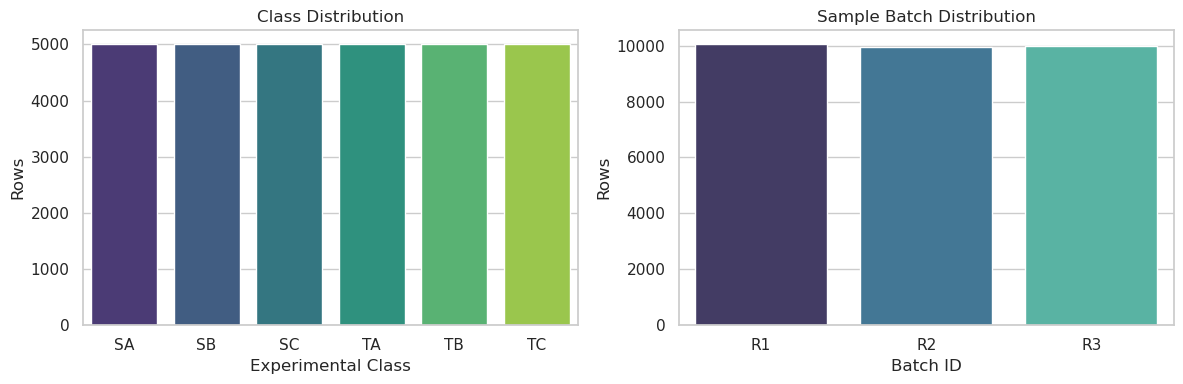

In [3]:
quality_summary = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'missing_count': df.isna().sum(),
    'missing_pct': df.isna().mean().mul(100),
    'unique_values': df.nunique(),
})

display(quality_summary)
print(f'Duplicate rows: {df.duplicated().sum():,}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=df, x='Class', order=sorted(df['Class'].unique()), ax=axes[0], palette='viridis', hue='Class', legend=False)
axes[0].set_title('Class Distribution')
axes[0].set_xlabel('Experimental Class')
axes[0].set_ylabel('Rows')

sns.countplot(data=df, x='Random', order=sorted(df['Random'].unique()), ax=axes[1], palette='mako', hue='Random', legend=False)
axes[1].set_title('Sample Batch Distribution')
axes[1].set_xlabel('Batch ID')
axes[1].set_ylabel('Rows')

plt.tight_layout()
plt.show()

## Numeric Summary

Summarize central tendency and spread for all continuous plant growth metrics.

In [4]:
numeric_cols = df.select_dtypes(include='number').columns.tolist()

summary = df[numeric_cols].describe().T
summary['iqr'] = summary['75%'] - summary['25%']
summary['skew'] = df[numeric_cols].skew()
summary['kurtosis'] = df[numeric_cols].kurtosis()
display(summary)

,count,mean,std,min,25%,50%,75%,max,iqr,skew,kurtosis
ACHP,30000.0,38.061,4.442,32.664,34.400,36.576,42.301,46.432,7.901,0.595,-1.050
PHR,30000.0,59.020,11.985,37.020,51.059,55.912,67.069,77.041,16.010,-0.201,-0.971
AWWGV,30000.0,1.247,0.246,0.848,1.065,1.211,1.502,1.775,0.437,0.337,-1.010
ALAP,30000.0,1063.640,260.713,658.488,875.501,1009.249,1243.867,1751.032,368.365,0.769,0.570
ANPL,30000.0,3.945,0.703,2.959,3.013,3.999,4.016,5.037,1.003,0.077,-0.974
ARD,30000.0,16.286,2.883,11.076,13.933,16.248,18.203,23.326,4.269,0.501,0.045
ADWR,30000.0,1.001,0.456,0.242,0.676,0.834,1.314,2.197,0.638,0.748,0.232
PDMVG,30000.0,22.675,9.571,8.022,14.981,21.954,27.711,43.660,12.730,0.584,-0.576
ARL,30000.0,18.071,2.933,12.360,15.600,18.477,20.365,23.253,4.765,-0.182,-0.806
AWWR,30000.0,2.907,1.362,1.127,1.911,2.819,3.254,6.909,1.343,1.251,1.585


## Distributions By Feature

Histograms show the overall shape of each numeric variable. Many variables are expected to be multi-modal because the dataset combines multiple experimental classes.

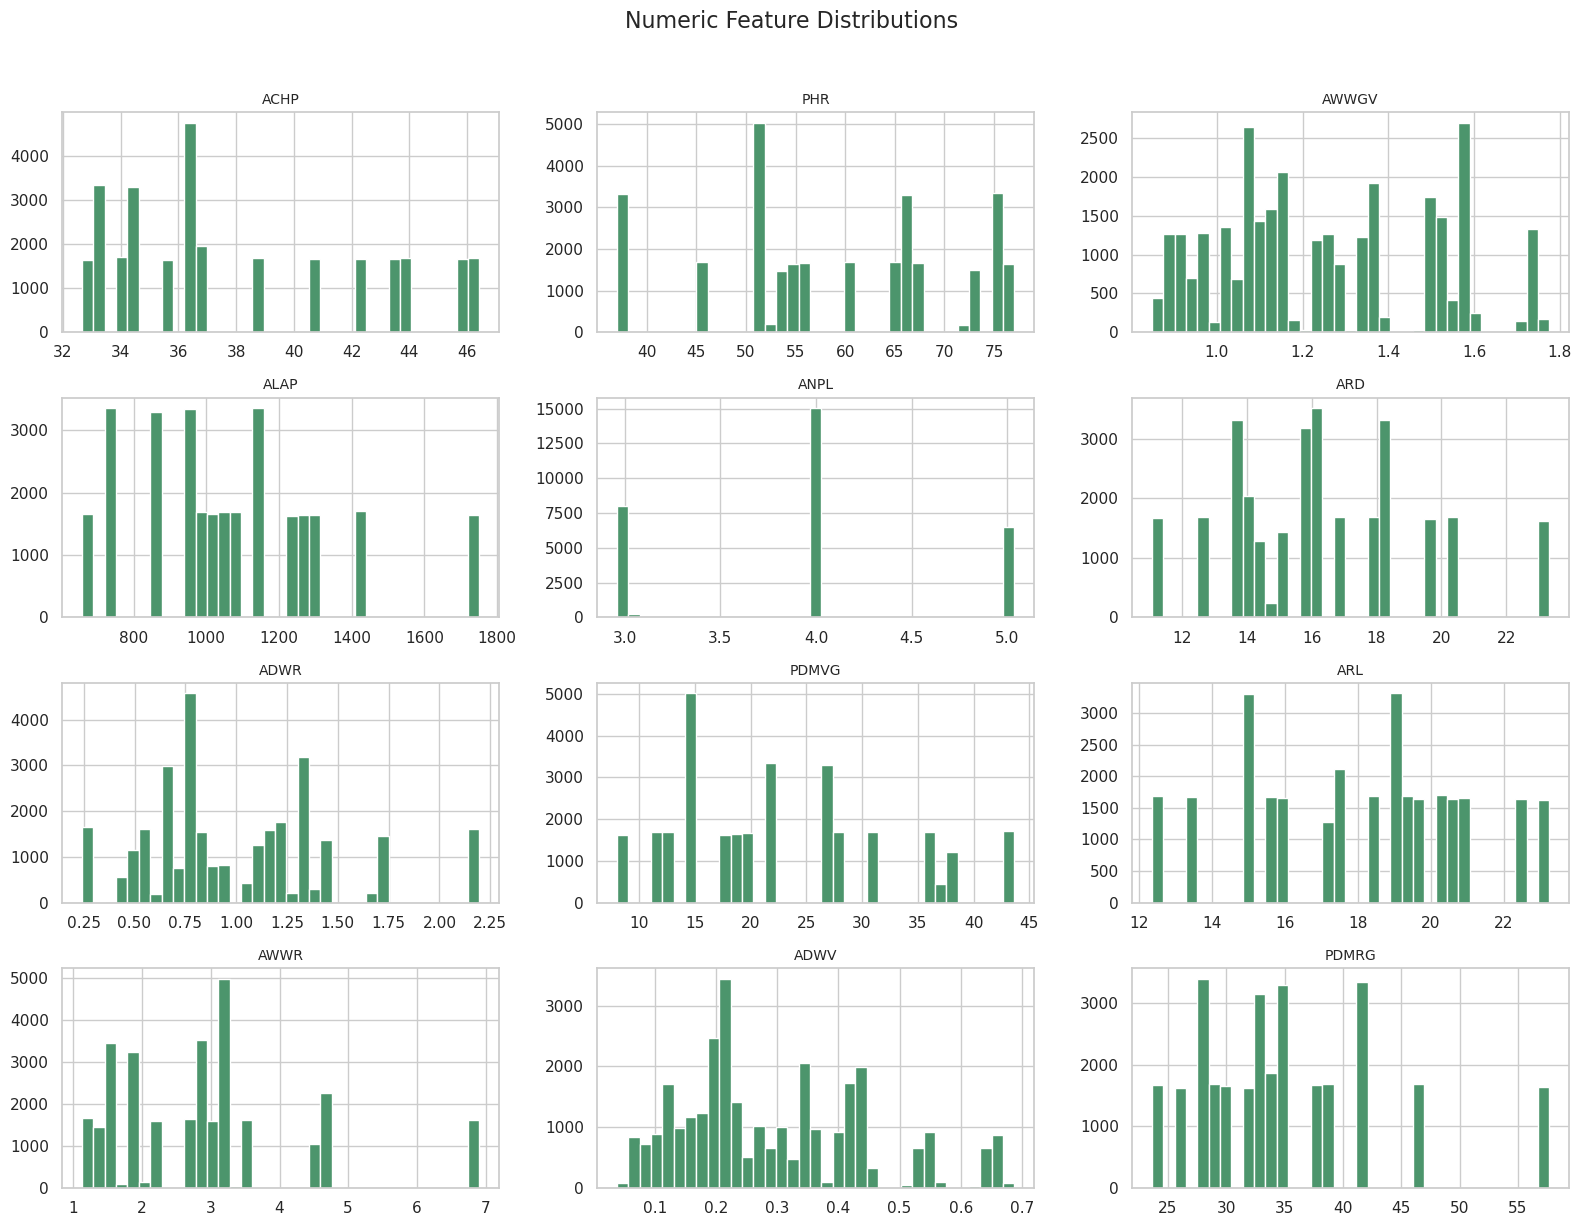

In [5]:
axes = df[numeric_cols].hist(bins=35, figsize=(16, 12), color='#4c956c', edgecolor='white')
for ax in axes.ravel():
    ax.set_title(ax.get_title(), fontsize=10)
plt.suptitle('Numeric Feature Distributions', y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

## Class-Level Differences

Boxplots compare each numeric feature across experimental classes.

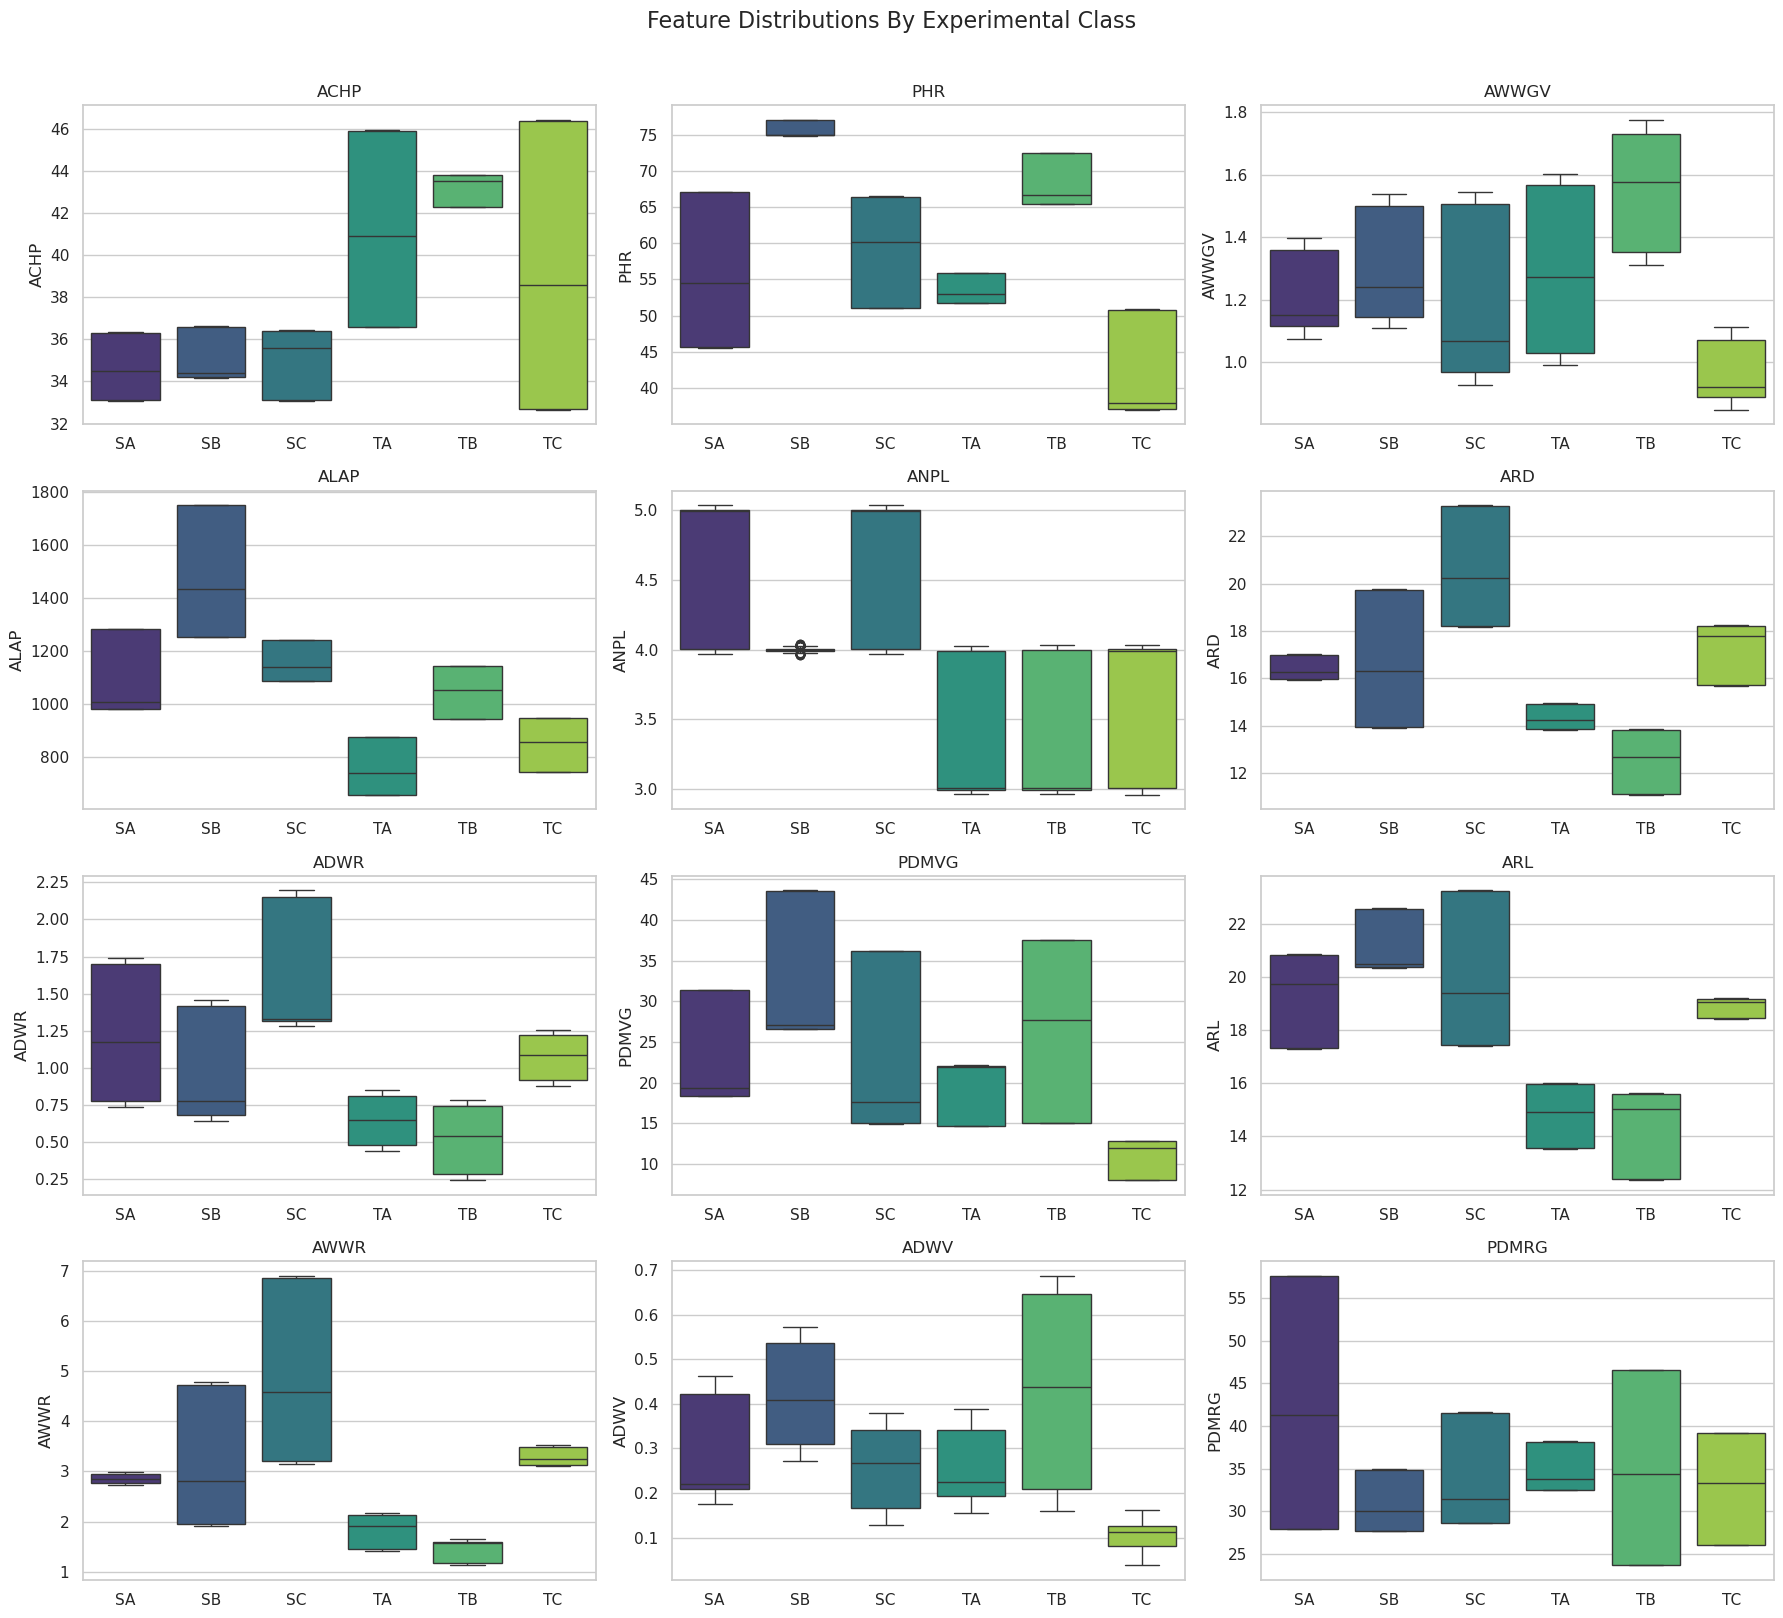

In [6]:
fig, axes = plt.subplots(4, 3, figsize=(18, 16))
class_order = sorted(df['Class'].unique())
for ax, col in zip(axes.ravel(), numeric_cols):
    sns.boxplot(data=df, x='Class', y=col, order=class_order, ax=ax, hue='Class', palette='viridis', legend=False)
    ax.set_title(col)
    ax.set_xlabel('')
plt.suptitle('Feature Distributions By Experimental Class', y=1.01, fontsize=16)
plt.tight_layout()
plt.show()

## Grouped Descriptive Statistics

Compare class means for each numeric feature. The heatmap uses standardized class means so features with different units can be compared visually.

,ACHP,PHR,AWWGV,ALAP,ANPL,ARD,ADWR,PDMVG,ARL,AWWR,ADWV,PDMRG
Class,,,,,,,,,,,,
SA,34.646,55.669,1.210,1090.343,4.661,16.418,1.213,23.144,19.287,2.855,0.286,42.137
SB,35.056,75.633,1.294,1479.668,4.000,16.650,0.956,32.573,21.124,3.154,0.419,30.836
SC,35.024,59.131,1.177,1156.175,4.663,20.546,1.595,23.012,19.977,4.863,0.258,33.927
TA,41.126,53.562,1.290,757.788,3.333,14.339,0.643,19.597,14.814,1.830,0.253,34.794
TB,43.201,68.149,1.553,1047.547,3.337,12.528,0.522,26.734,14.331,1.447,0.430,34.905
TC,39.309,41.978,0.960,850.318,3.675,17.233,1.077,10.987,18.894,3.293,0.106,32.933


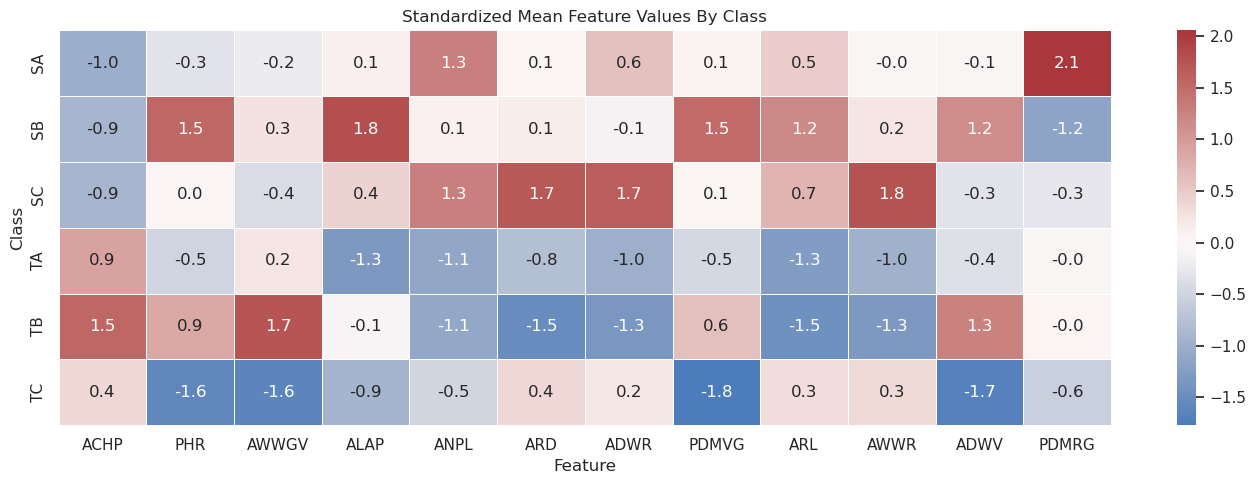

In [7]:
class_means = df.groupby('Class')[numeric_cols].mean().loc[class_order]
display(class_means)

scaled_class_means = pd.DataFrame(
    StandardScaler().fit_transform(class_means),
    index=class_means.index,
    columns=class_means.columns,
)

plt.figure(figsize=(14, 5))
sns.heatmap(scaled_class_means, cmap='vlag', center=0, annot=True, fmt='.1f', linewidths=0.5)
plt.title('Standardized Mean Feature Values By Class')
plt.xlabel('Feature')
plt.ylabel('Class')
plt.tight_layout()
plt.show()

## Batch Effects

The `Random` column indicates sample batch IDs (`R1`, `R2`, `R3`). This section checks whether batches are evenly represented within each class.

Random,R1,R2,R3
Class,,,
SA,1646,1658,1696
SB,1706,1647,1647
SC,1690,1683,1627
TA,1665,1662,1673
TB,1647,1684,1669
TC,1691,1625,1684


Random,R1,R2,R3
Class,,,
SA,32.92,33.16,33.92
SB,34.12,32.94,32.94
SC,33.80,33.66,32.54
TA,33.30,33.24,33.46
TB,32.94,33.68,33.38
TC,33.82,32.50,33.68


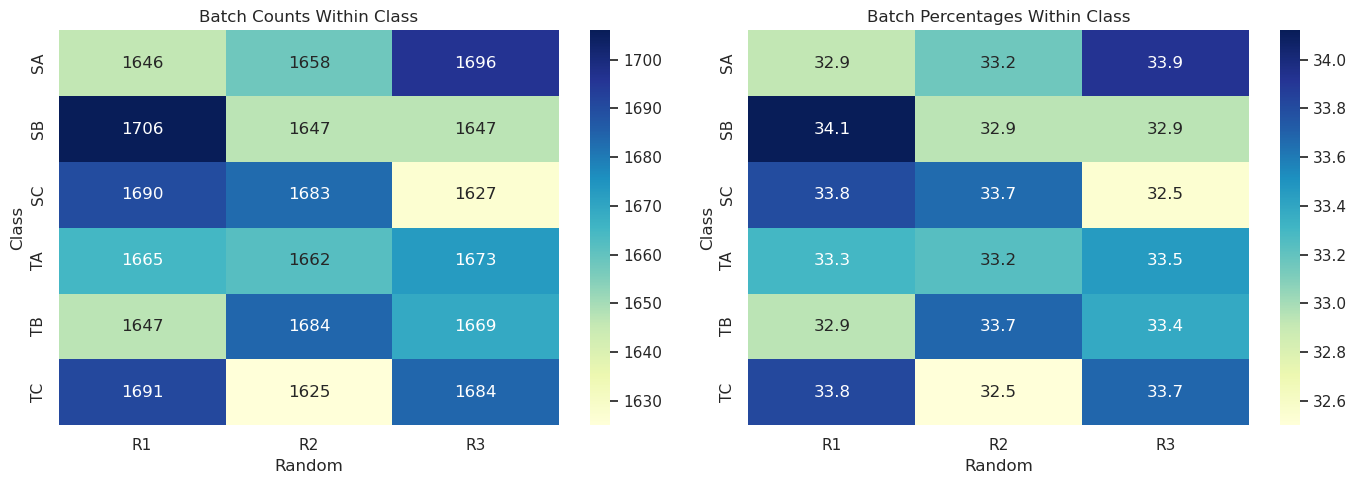

In [8]:
batch_class_counts = pd.crosstab(df['Class'], df['Random'])
batch_class_pct = pd.crosstab(df['Class'], df['Random'], normalize='index').mul(100)

display(batch_class_counts)
display(batch_class_pct.round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(batch_class_counts, annot=True, fmt='d', cmap='YlGnBu', ax=axes[0])
axes[0].set_title('Batch Counts Within Class')

sns.heatmap(batch_class_pct, annot=True, fmt='.1f', cmap='YlGnBu', ax=axes[1])
axes[1].set_title('Batch Percentages Within Class')
plt.tight_layout()
plt.show()

## Correlation Structure

Correlations help identify redundant measurements and groups of related plant traits.

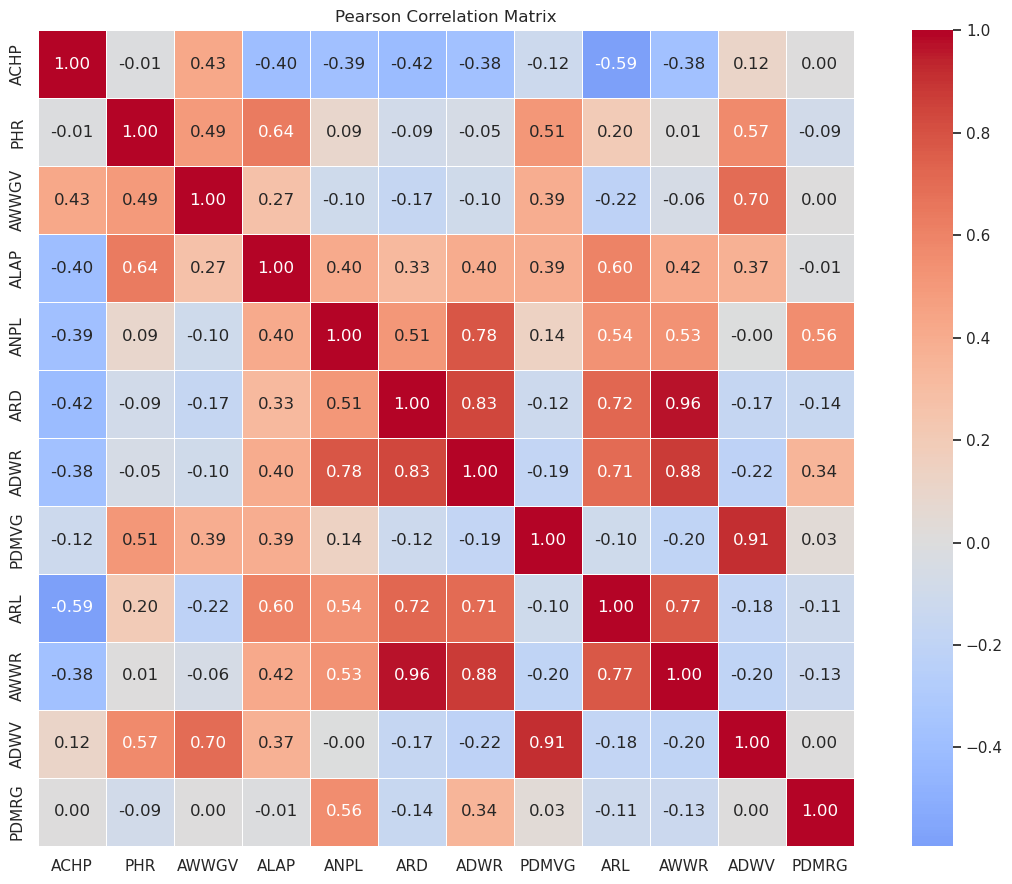

,feature_1,feature_2,correlation,abs_correlation
69,ARD,AWWR,0.963,0.963
94,PDMVG,ADWV,0.914,0.914
81,ADWR,AWWR,0.877,0.877
66,ARD,ADWR,0.833,0.833
54,ANPL,ADWR,0.778,0.778
105,ARL,AWWR,0.772,0.772
68,ARD,ARL,0.722,0.722
80,ADWR,ARL,0.706,0.706
34,AWWGV,ADWV,0.701,0.701
15,PHR,ALAP,0.636,0.636


In [9]:
corr = df[numeric_cols].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=True, fmt='.2f', square=True, linewidths=0.4)
plt.title('Pearson Correlation Matrix')
plt.tight_layout()
plt.show()

corr_pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    .stack()
    .rename('correlation')
    .reset_index()
    .rename(columns={'level_0': 'feature_1', 'level_1': 'feature_2'})
)
corr_pairs['abs_correlation'] = corr_pairs['correlation'].abs()
display(corr_pairs.sort_values('abs_correlation', ascending=False).head(15))

## PCA Overview

Principal Component Analysis (PCA) projects the standardized numeric features into two dimensions to show class separability.

PC1 explains 38.25% of variance
PC2 explains 26.41% of variance
Combined PC1 + PC2 explains 64.66% of variance


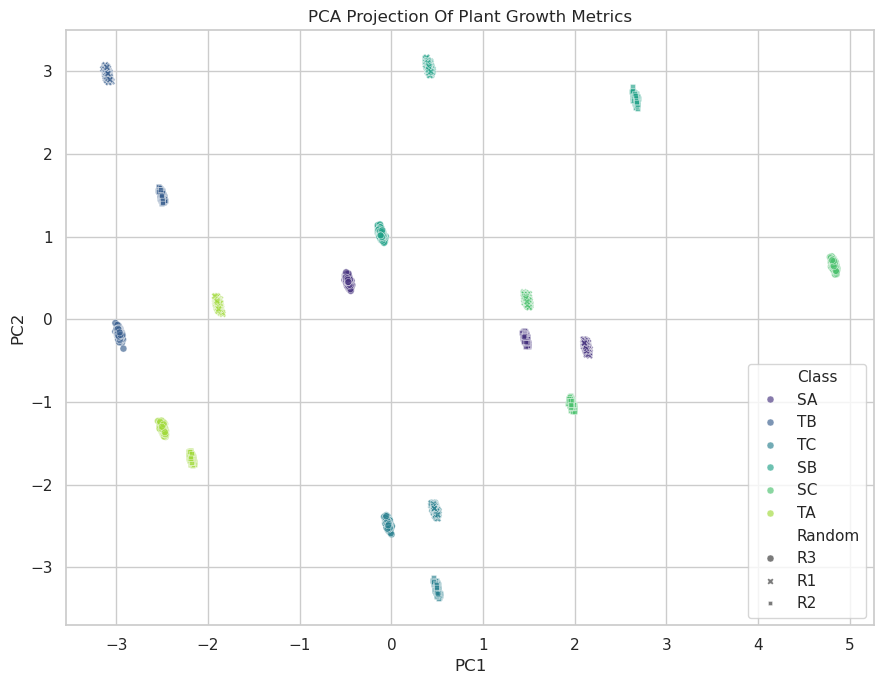

,PC1_loading,PC2_loading,abs_PC1
ADWR,0.430,-0.023,0.430
AWWR,0.424,-0.014,0.424
ARL,0.413,0.041,0.413
ARD,0.412,-0.037,0.412
ANPL,0.345,0.093,0.345
ACHP,-0.286,-0.007,0.286
ALAP,0.254,0.372,0.254
AWWGV,-0.112,0.395,0.112
ADWV,-0.106,0.512,0.106
PDMVG,-0.056,0.473,0.056


In [10]:
X_scaled = StandardScaler().fit_transform(df[numeric_cols])
pca = PCA(n_components=2, random_state=RANDOM_STATE)
pca_scores = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(pca_scores, columns=['PC1', 'PC2'])
pca_df['Class'] = df['Class']
pca_df['Random'] = df['Random']

explained = pca.explained_variance_ratio_ * 100
print(f'PC1 explains {explained[0]:.2f}% of variance')
print(f'PC2 explains {explained[1]:.2f}% of variance')
print(f'Combined PC1 + PC2 explains {explained.sum():.2f}% of variance')

sample_for_plot = pca_df.sample(n=min(6000, len(pca_df)), random_state=RANDOM_STATE)
plt.figure(figsize=(9, 7))
sns.scatterplot(data=sample_for_plot, x='PC1', y='PC2', hue='Class', style='Random', s=25, alpha=0.65, palette='viridis')
plt.title('PCA Projection Of Plant Growth Metrics')
plt.tight_layout()
plt.show()

loadings = pd.DataFrame(
    pca.components_.T,
    index=numeric_cols,
    columns=['PC1_loading', 'PC2_loading'],
)
display(loadings.assign(abs_PC1=loadings['PC1_loading'].abs()).sort_values('abs_PC1', ascending=False))

## One-Way ANOVA Across Classes

For each numeric metric, run a one-way ANOVA across experimental classes. With a large and balanced dataset, very small p-values indicate that the feature differs strongly by class.

,feature,f_statistic,p_value
1,PHR,24224.153,0.0
3,ALAP,22398.696,0.0
8,ARL,20007.389,0.0
5,ARD,17462.090,0.0
9,AWWR,11565.883,0.0
4,ANPL,9962.863,0.0
6,ADWR,9429.532,0.0
0,ACHP,7900.506,0.0
10,ADWV,6650.430,0.0
2,AWWGV,6325.453,0.0


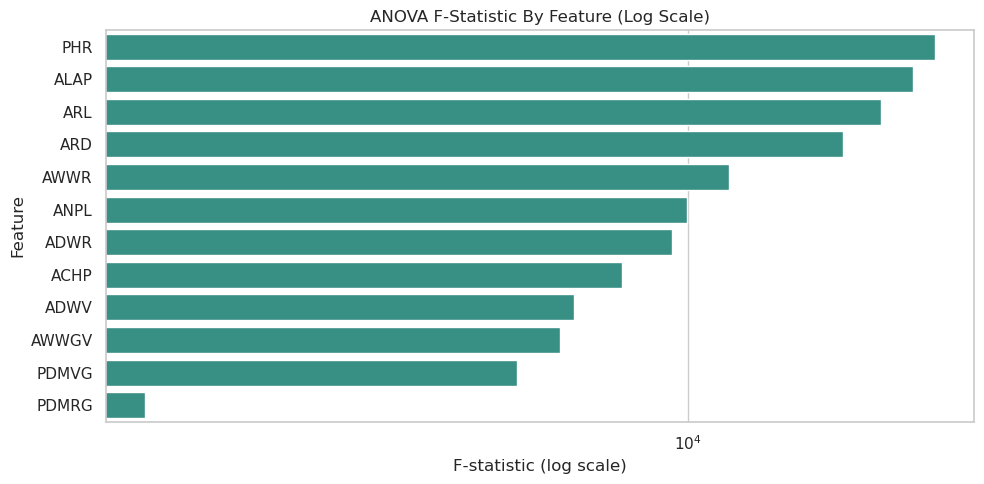

In [11]:
anova_rows = []
for col in numeric_cols:
    groups = [group[col].to_numpy() for _, group in df.groupby('Class')]
    f_stat, p_value = stats.f_oneway(*groups)
    anova_rows.append({'feature': col, 'f_statistic': f_stat, 'p_value': p_value})

anova = pd.DataFrame(anova_rows).sort_values('f_statistic', ascending=False)
display(anova)

plt.figure(figsize=(10, 5))
sns.barplot(data=anova, y='feature', x='f_statistic', color='#2a9d8f')
plt.xscale('log')
plt.title('ANOVA F-Statistic By Feature (Log Scale)')
plt.xlabel('F-statistic (log scale)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## Key Findings

- The dataset contains 30,000 rows, 14 columns, no missing values, and no duplicate rows.
- The six experimental classes are perfectly balanced with 5,000 rows each.
- Batch IDs are close to balanced overall, but their distribution should still be checked within classes before modeling.
- Several features show strong class separation, especially in the class-level boxplots, standardized mean heatmap, and PCA projection.
- The correlation heatmap identifies highly related measurements, which may matter for downstream modeling or feature selection.
- ANOVA results indicate that numeric plant growth metrics differ substantially across experimental classes.